In [12]:
import pandas as pd
import scipy.stats as stats

reference_data = pd.read_csv("./data/reference_data.csv")
prod_log = pd.read_json("./logs/prediction.jsonl", lines=True)
prod_input = pd.DataFrame(prod_log["input"].tolist())
shift_log = pd.read_json("./logs/prediction_shift.jsonl", lines=True)
shift_input = pd.DataFrame(shift_log["input"].tolist())

FEATURE_MAP = {"air_temp": "Air temperature [K]", "process_temp": "Process temperature [K]",
               "rot_speed": "Rotational speed [rpm]", "torque": "Torque [Nm]", "tool_wear": "Tool wear [min]",
               "product_type": "Type"}

NUM_FEATURES = [v for v in FEATURE_MAP.values() if v != "Type"]

prod_input = prod_input.rename(columns=FEATURE_MAP)
shift_input = shift_input.rename(columns=FEATURE_MAP)

def drift_report(reference, current, features):
    report = []
    for feature in features:
        res = stats.ks_2samp(reference[feature], current[feature])
        report.append({"feature": feature, "D": res.statistic, "p": res.pvalue, "drift": (res.pvalue < 0.01 and res.statistic > 0.1)})
    return pd.DataFrame(report)

prod_drift_report = drift_report(reference_data, prod_input, NUM_FEATURES)
shift_drift_report = drift_report(reference_data, shift_input, NUM_FEATURES)

print(shift_drift_report)

shift_log.value_counts("failure_predicted")
# prod_log.value_counts("failure_predicted")



                   feature         D              p  drift
0      Air temperature [K]  0.018625   6.314555e-01  False
1  Process temperature [K]  0.674125  2.391278e-321   True
2   Rotational speed [rpm]  0.337125  6.072356e-162   True
3              Torque [Nm]  0.017000   7.402219e-01  False
4          Tool wear [min]  0.011750   9.789097e-01  False


failure_predicted
False    1974
True       26
Name: count, dtype: int64

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

base_p = prod_log["failure_probability"]
shift_p = shift_log["failure_probability"]
threshold = prod_log["threshold"].iloc[0]

# Lage und hohe Perzentile
percentiles = [0.5, 0.9, 0.95, 0.99]
summary = pd.DataFrame({
    "baseline": base_p.describe(percentiles=percentiles),
    "shifted": shift_p.describe(percentiles=percentiles),
})

# Anteil der Vorhersagen oberhalb fester Grenzen
levels = [0.1, 0.3, threshold]
tail = pd.DataFrame({
    "baseline": [(base_p >= l).mean() for l in levels],
    "shifted": [(shift_p >= l).mean() for l in levels],
}, index=[f">= {l}" for l in levels])

ks = ks_2samp(base_p, shift_p)
print(f"KS: D={ks.statistic:.3f}, p={ks.pvalue:.2e}")
summary, tail

KS: D=0.320, p=1.22e-90


(          baseline      shifted
 count  2000.000000  2000.000000
 mean      0.048362     0.043838
 std       0.142963     0.098714
 min       0.000000     0.000000
 50%       0.000000     0.015000
 90%       0.115000     0.085000
 95%       0.330250     0.235000
 99%       0.790100     0.540000
 max       0.945000     0.835000,
         baseline  shifted
 >= 0.1     0.108   0.0910
 >= 0.3     0.055   0.0405
 >= 0.5     0.033   0.0130)

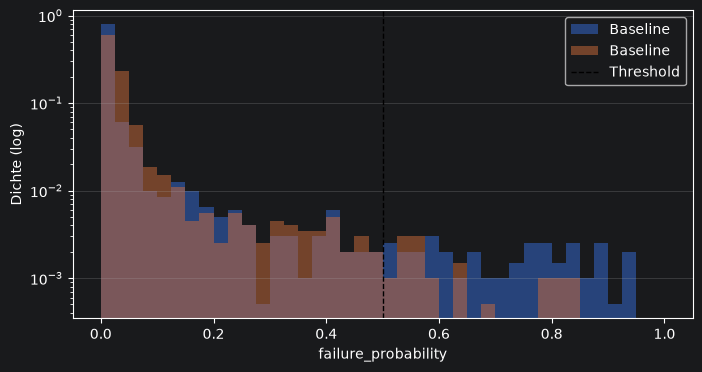

In [16]:
bins = np.linspace(0, 1, 41)   # gleiche Bins für beide, sonst nicht vergleichbar

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(base_p, bins=bins, weights=np.ones(len(base_p)) / len(base_p), alpha=0.5, label="Baseline")
ax.hist(shift_p, bins=bins, weights=np.ones(len(base_p)) / len(base_p), alpha=0.5, label="Baseline")
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label="Threshold")
ax.set_yscale("log")
ax.set_xlabel("failure_probability")
ax.set_ylabel("Dichte (log)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()

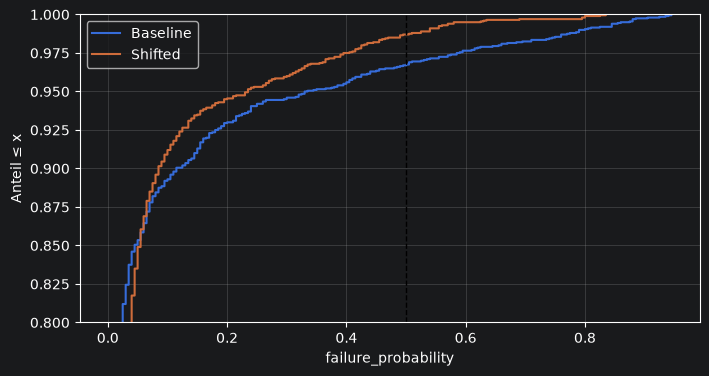

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
for data, label in [(base_p, "Baseline"), (shift_p, "Shifted")]:
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", label=label, linewidth=1.5)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("failure_probability")
ax.set_ylabel("Anteil ≤ x")
ax.set_ylim(0.8, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [21]:
from sklearn.metrics import recall_score, precision_score, f1_score

prod_origin_data = pd.read_csv("./data/production_data.csv")

[precision_score(prod_origin_data["Machine failure"], shift_log["failure_predicted"]),
recall_score(prod_origin_data["Machine failure"], shift_log["failure_predicted"]),
f1_score(prod_origin_data["Machine failure"], shift_log["failure_predicted"])]


[0.7692307692307693, 0.29411764705882354, 0.425531914893617]